In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

In [185]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [186]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [187]:
X = df.drop("Revenue", axis = 1)
y = df["Revenue"].astype(int)

In [188]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


In [189]:
num_features = X.select_dtypes(include = ["int64", "float64"]).columns
cat_features = X.select_dtypes(include = ["object", "category"]).columns

In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [191]:
# Feature Preprocessing Pipeline
preprocessor = ColumnTransformer (
    transformers = [
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), cat_features)
    ]
)

In [192]:
#Decision Tree Classifier
dt = DecisionTreeClassifier(
    max_depth = 5, 
    min_samples_leaf = 30,
    class_weight = "balanced",
    random_state = 42
)

In [193]:
pipe = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", dt)
    ]
)

In [194]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [195]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


In [196]:
y_pred = pipe.predict(X_test)

In [197]:
print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6378676470588235

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.84      0.90      2055
           1       0.51      0.84      0.64       411

    accuracy                           0.84      2466
   macro avg       0.74      0.84      0.77      2466
weighted avg       0.89      0.84      0.85      2466


Confusion Matrix:
 [[1725  330]
 [  64  347]]


In [198]:
#HyperParameter Tuning

param_grid = {
    "model__max_depth" : [2, 3, 4, 5, 6, 8],
    "model__min_samples_leaf" :[10, 20, 30, 40, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring = "f1",
    cv = 5,
    n_jobs = -1
)
grid.fit(X_train, y_train)

print("Best F1", grid.best_score_)
print("Best Params", grid.best_params_)

Best F1 0.6599842366229802
Best Params {'model__max_depth': 2, 'model__min_samples_leaf': 10}


In [199]:
#Best Model 

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

F1 score: 0.676200204290092

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92      2055
           1       0.58      0.81      0.68       411

    accuracy                           0.87      2466
   macro avg       0.77      0.85      0.80      2466
weighted avg       0.90      0.87      0.88      2466


Confusion Matrix:
 [[1818  237]
 [  80  331]]


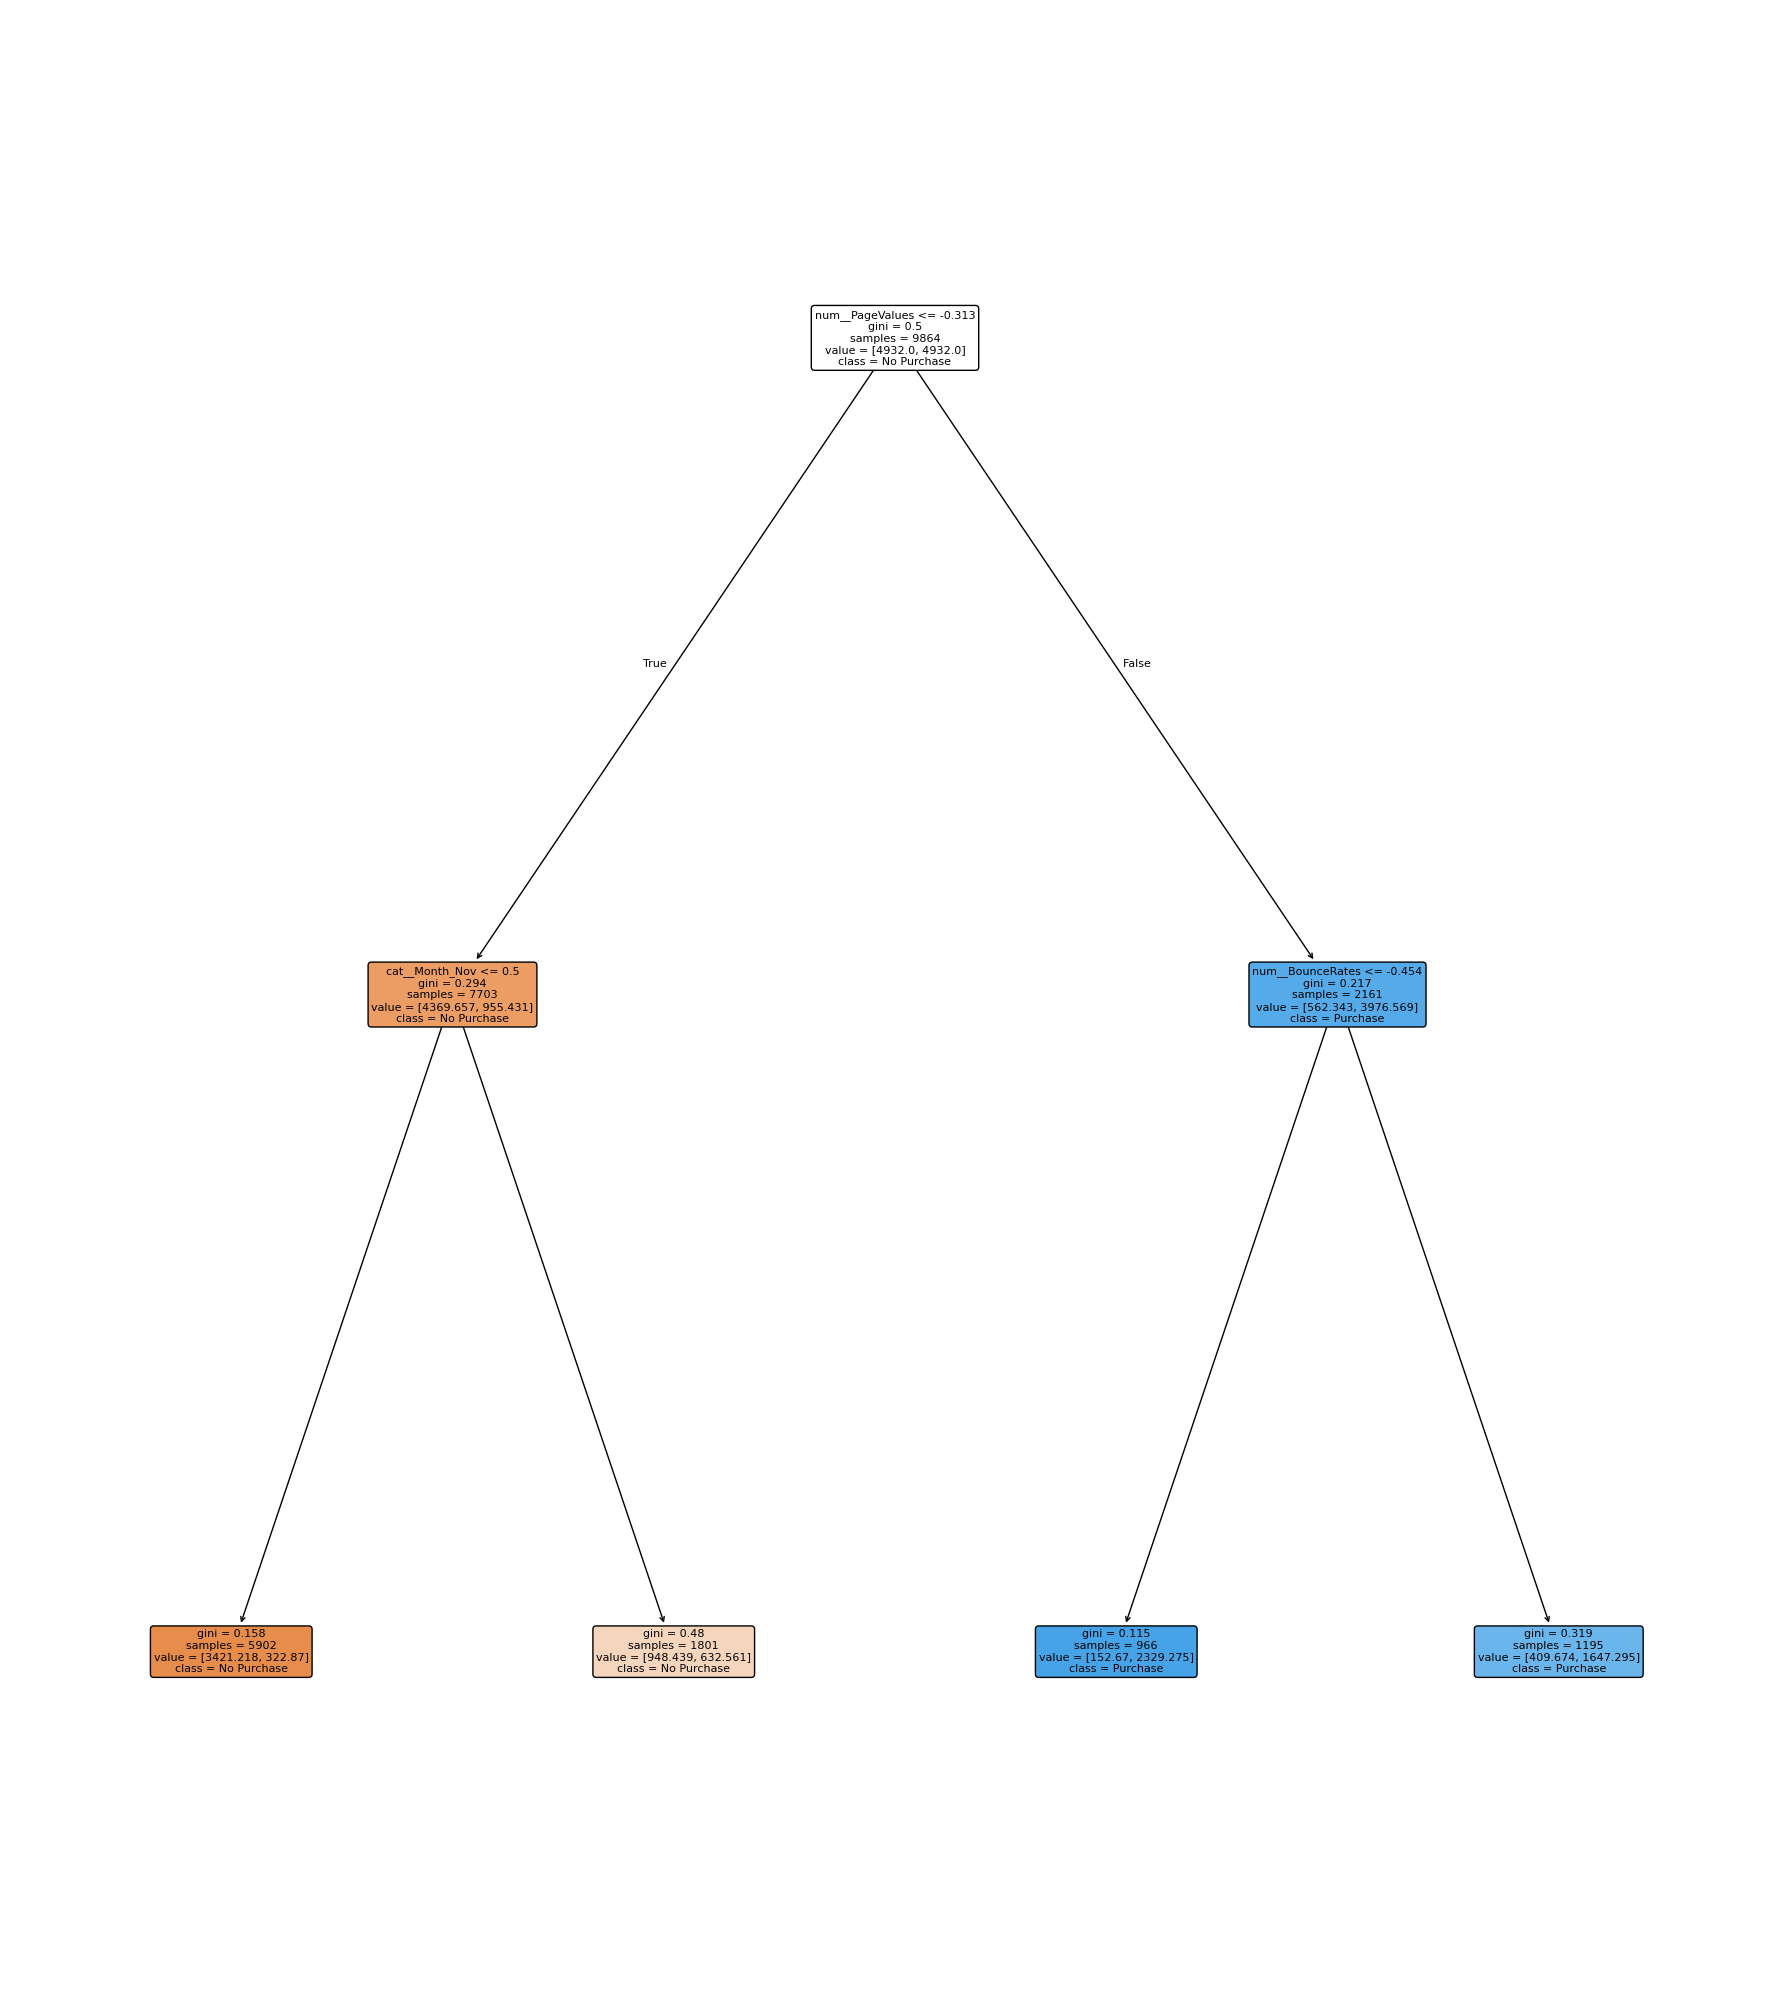

In [201]:
#Plot a tree based on our best model

best_tree = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize = (18, 20))
plot_tree(
    best_tree,
    feature_names = feature_names,
    class_names=["No Purchase", "Purchase"],
    filled = True,
    rounded = True,
    fontsize = 8
)

plt.tight_layout()
plt.show()